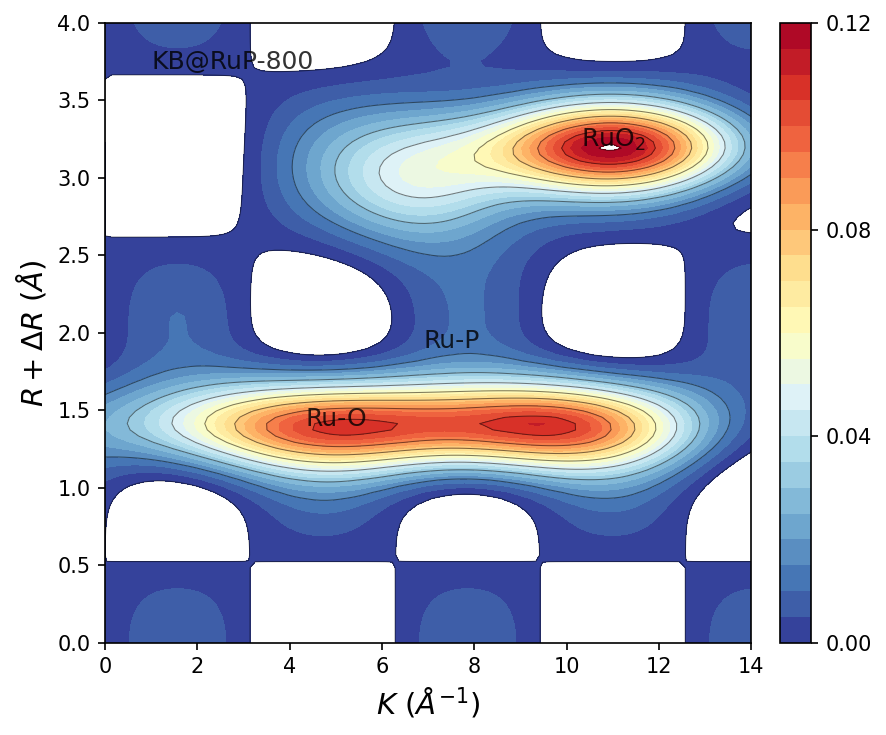

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# --- Data Simulation ---
k_val = np.linspace(0, 14, 100)
r_val = np.linspace(0, 4, 100)
K, R = np.meshgrid(k_val, r_val)

def gaussian_2d(k, r, k0, r0, sk, sr, A):
    return A * np.exp(-((k - k0)**2)/(2*sk**2) - ((r - r0)**2)/(2*sr**2))

# Lobes
Z = np.zeros_like(K)

# Ru-O (Low R, wide K)
Z += gaussian_2d(K, R, 5, 1.4, 3, 0.2, 0.1)
Z += gaussian_2d(K, R, 10, 1.4, 2, 0.2, 0.08)

# Ru-P / RuO2 (High R)
Z += gaussian_2d(K, R, 11, 3.2, 2, 0.2, 0.11)
Z += gaussian_2d(K, R, 7, 3.0, 1.5, 0.3, 0.05) # Bridge

# Background noise/ripples
Z += 0.01 * np.sin(K) * np.cos(R*3)

# --- Plotting ---
fig, ax = plt.subplots(figsize=(6, 5), dpi=150)

# Contourf
levels = np.linspace(0, 0.12, 25)
cmap = plt.cm.RdYlBu_r # Red-Yellow-Blue reversed
cf = ax.contourf(K, R, Z, levels=levels, cmap=cmap)
# Contour lines
ax.contour(K, R, Z, levels=levels[::3], colors='black', linewidths=0.5, alpha=0.5)

# Colorbar
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04)
cbar.set_ticks([0, 0.04, 0.08, 0.12])

# Labels
ax.text(1, 3.7, 'KB@RuP-800', fontsize=12, alpha=0.8)
ax.text(5, 1.4, 'Ru-O', ha='center', fontsize=12, alpha=0.8)
ax.text(11, 3.2, 'RuO$_2$', ha='center', fontsize=12, alpha=0.8)
ax.text(7.5, 1.9, 'Ru-P', ha='center', fontsize=12, alpha=0.8)

# Styling
ax.set_xlabel(r'$K$ ($\AA^{-1}$)', fontsize=14)
ax.set_ylabel(r'$R + \Delta R$ ($\AA$)', fontsize=14)
ax.set_xlim(0, 14)
ax.set_ylim(0, 4)

# Ticks
ax.tick_params(direction='out', top=False, right=False)

plt.tight_layout()
plt.show()
